
     MODULE 1: ADVANCED MACHINE LEARNING TECHNIQUES                   
     House Price Prediction - Ensemble vs Deep Learning Comparison    

- **Student:** Obasi-Uzoma Blessing
- **Level:** Intermediate
- **Date:** Friday, 23rd of January 2026

##### **PROJECT OBJECTIVE:**
Compare the predictive power of traditional ensemble methods (Bagging and
Boosting) against modern Deep Learning approaches (Multi-Layer Perceptron)
using a real-world house price dataset.

**TECHNIQUES DEMONSTRATED:**
- Random Forest (Bagging)
- Gradient Boosting (Boosting)  
- Multi-Layer Perceptron (Deep Neural Network)
- Feature Engineering
- Model Evaluation & Comparison

**Table of Contents**
1. [Data Loading & Exploration](#data-loading)
2. [Exploratory Data Analysis](#eda)
3. [Data Preprocessing](#preprocessing)
4. [Model Training - Ensemble Methods](#ensemble)
5. [Model Training - Deep Learning](#deep-learning)
6. [Model Evaluation & Comparison](#evaluation)
7. [Conclusions & Insights](#conclusions)



---
# 1. Data Loading & Exploration

In this section, we download the dataset from Kaggle and perform initial exploration to understand the data structure.

In [49]:
## --- Setup and Data Loading ---

import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

# 1. Download the dataset
path = kagglehub.dataset_download("anmolkumar/house-price-prediction-challenge")

print("Path to dataset files:", path)

# 2. Load the CSV files
# We look for the csv files inside that path.
train_path = os.path.join(path, "train.csv")
test_path = os.path.join(path, "test.csv")

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Display the first few rows to understand the structure
print("Train Shape:", df_train.shape)
display(df_train.head())

Using Colab cache for faster access to the 'house-price-prediction-challenge' dataset.
Path to dataset files: /kaggle/input/house-price-prediction-challenge
Train Shape: (29451, 12)


,POSTED_BY,UNDER_CONSTRUCTION,RERA,BHK_NO.,BHK_OR_RK,SQUARE_FT,READY_TO_MOVE,RESALE,ADDRESS,LONGITUDE,LATITUDE,TARGET(PRICE_IN_LACS)
0,Owner,0,0,2,BHK,1300.236407,1,1,"Ksfc Layout,Bangalore",12.969910,77.597960,55.0
1,Dealer,0,0,2,BHK,1275.000000,1,1,"Vishweshwara Nagar,Mysore",12.274538,76.644605,51.0
2,Owner,0,0,2,BHK,933.159722,1,1,"Jigani,Bangalore",12.778033,77.632191,43.0
3,Owner,0,1,2,BHK,929.921143,1,1,"Sector-1 Vaishali,Ghaziabad",28.642300,77.344500,62.5
4,Dealer,1,0,2,BHK,999.009247,0,1,"New Town,Kolkata",22.592200,88.484911,60.5


---
# 2. Exploratory Data Analysis

We analyze the distribution of features, check for missing values, and visualize relationships between variables and the target.

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29451 entries, 0 to 29450
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   POSTED_BY              29451 non-null  object 
 1   UNDER_CONSTRUCTION     29451 non-null  int64  
 2   RERA                   29451 non-null  int64  
 3   BHK_NO.                29451 non-null  int64  
 4   BHK_OR_RK              29451 non-null  object 
 5   SQUARE_FT              29451 non-null  float64
 6   READY_TO_MOVE          29451 non-null  int64  
 7   RESALE                 29451 non-null  int64  
 8   ADDRESS                29451 non-null  object 
 9   LONGITUDE              29451 non-null  float64
 10  LATITUDE               29451 non-null  float64
 11  TARGET(PRICE_IN_LACS)  29451 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 2.7+ MB
None

Missing Values:
POSTED_BY                0
UNDER_CONSTRUCTION       0
RERA

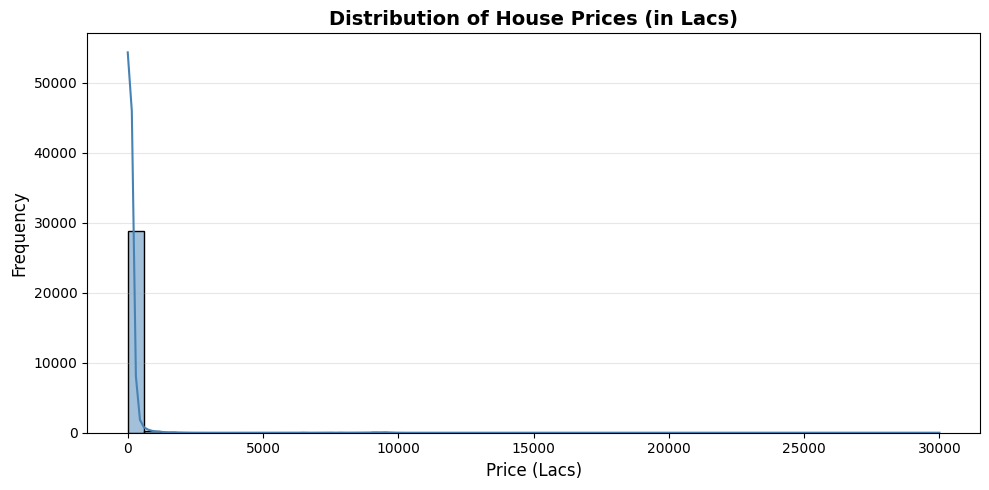


Target Variable Statistics:
count    29451.000000
mean       142.898746
std        656.880713
min          0.250000
25%         38.000000
50%         62.000000
75%        100.000000
max      30000.000000
Name: TARGET(PRICE_IN_LACS), dtype: float64


In [50]:
## --- Loaded Data Visualisation ---

# Basic Info
print("Dataset Information:")
print("="*50)
print(df_train.info())

# Check for missing values
print("\nMissing Values:")
print("="*50)
print(df_train.isnull().sum())

# Target Distribution
plt.figure(figsize=(10, 5))
sns.histplot(df_train['TARGET(PRICE_IN_LACS)'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices (in Lacs)', fontsize=14, fontweight='bold')
plt.xlabel('Price (Lacs)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Additional insights
print("\nTarget Variable Statistics:")
print("="*50)
print(df_train['TARGET(PRICE_IN_LACS)'].describe())

---
# 3. Data Preprocessing

Preparing data for machine learning by encoding categorical variables and splitting into train/validation sets.

In [51]:
## --- Data Preprocessing (Feature Engineering) ---

# 1. Identify Target and Features
X = df_train.drop(['TARGET(PRICE_IN_LACS)', 'ADDRESS'], axis=1) # Drop Address as it's too high cardinality
y = df_train['TARGET(PRICE_IN_LACS)']

# 2. Handle Categorical Columns (Label Encoding)
# I use Label Encoding here for the tree-based ensembles (like Random Forest) which handles it well.
categorical_cols = X.select_dtypes(include=['object']).columns

for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

# 3. Split Data into Training and Validation Sets
# I use 80% for training and 20% to test our ensemble performance
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Validation features shape:", X_val.shape)

Training features shape: (23560, 10)
Validation features shape: (5891, 10)


---
# 4. Ensemble Methods Training

Implementing and training two ensemble approaches:
- **Random Forest:** Bagging method that builds multiple decision trees in parallel
- **Gradient Boosting:** Boosting method that builds trees sequentially to correct errors

In [52]:
## --- Implementing Ensemble Models ---

# --- Model 1: Random Forest (Bagging) ---
# Combines multiple decision trees to reduce overfitting and improve variance.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_val)

# --- Model 2: Gradient Boosting (Boosting) ---
# Builds trees sequentially, where each new tree corrects errors of the previous one.
gb_model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_val)

print("Models Trained Successfully")

Models Trained Successfully


In [53]:
## --- Performance Evaluation ---

def evaluate_model(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Performance ---")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.4f}\n")

evaluate_model("Random Forest", y_val, rf_preds)
evaluate_model("Gradient Boosting", y_val, gb_preds)

--- Random Forest Performance ---
RMSE: 373.80
R2 Score: 0.7436

--- Gradient Boosting Performance ---
RMSE: 348.29
R2 Score: 0.7774




FEATURE IMPORTANCE ANALYSIS


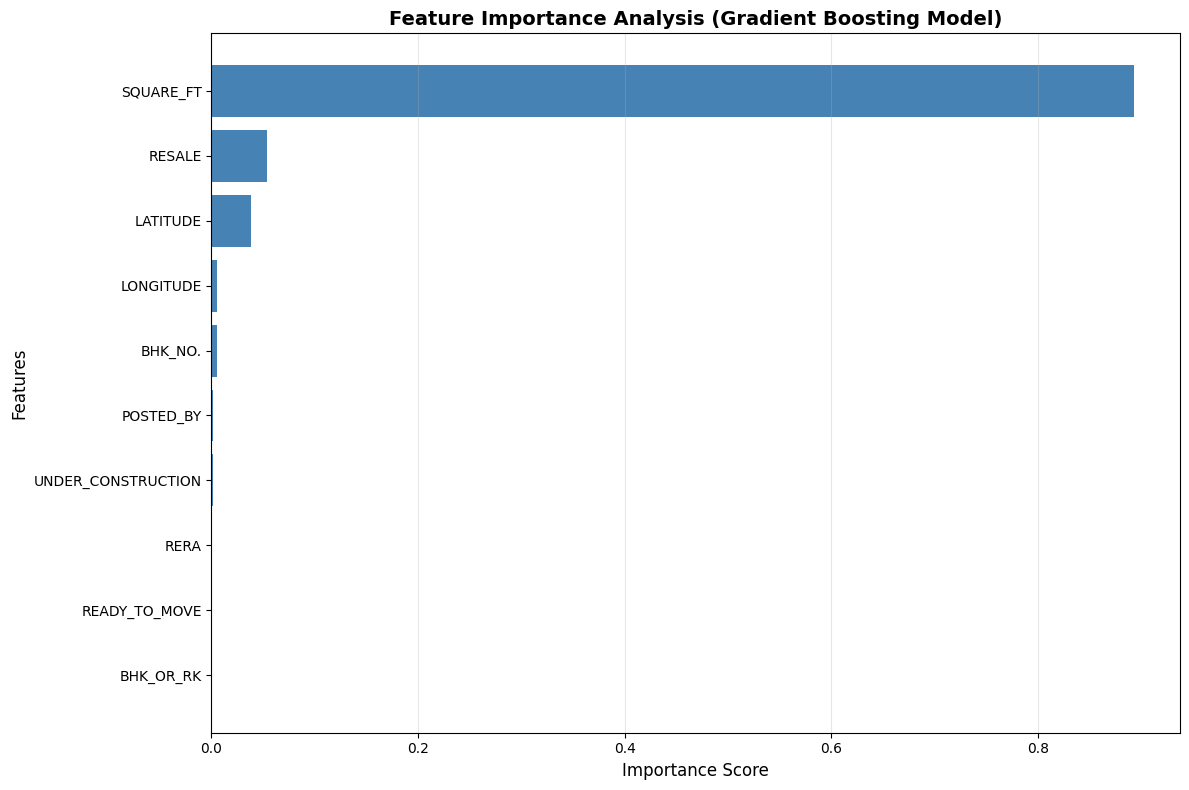


Top 5 Most Important Features:
BHK_NO.: 0.0055
LONGITUDE: 0.0058
LATITUDE: 0.0381
RESALE: 0.0534
SQUARE_FT: 0.8926


In [54]:
# Feature Importance Visualization (Advanced ML)

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)
feature_importance = gb_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better handling
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='steelblue')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Importance Analysis (Gradient Boosting Model)',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Print top features
print("\nTop 5 Most Important Features:")
print("="*50)
for idx, row in importance_df.tail(5).iterrows():
    print(f"{row['Feature']}: {row['Importance']:.4f}")


DEEPER DATA INSIGHTS


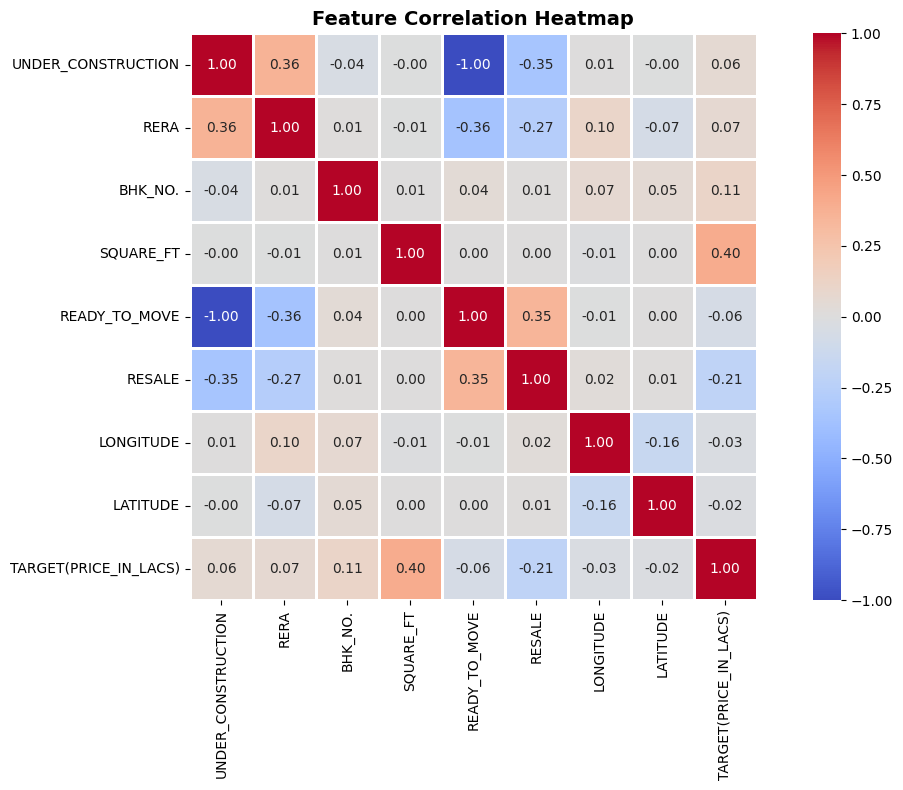

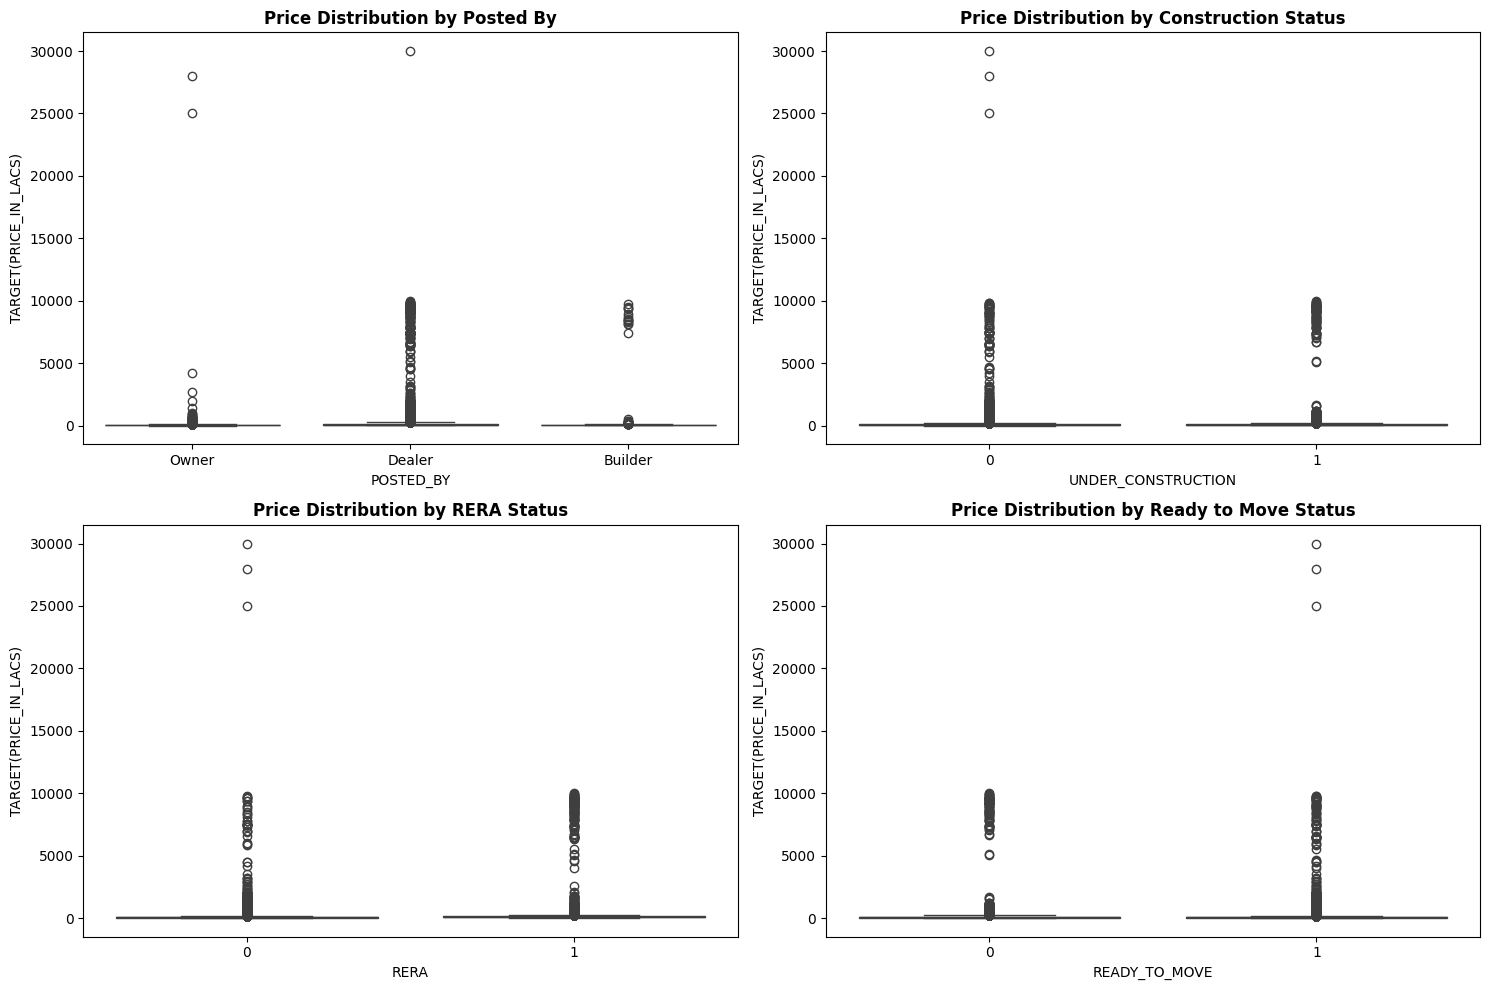

In [55]:
# Additional Exploratory Data Analysis
print("\n" + "="*60)
print("DEEPER DATA INSIGHTS")
print("="*60)

# Correlation Analysis
plt.figure(figsize=(12, 8))
correlation_matrix = df_train.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Price distribution by categorical features
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Posted By
sns.boxplot(data=df_train, x='POSTED_BY', y='TARGET(PRICE_IN_LACS)', ax=axes[0,0])
axes[0,0].set_title('Price Distribution by Posted By', fontweight='bold')

# Under Construction
sns.boxplot(data=df_train, x='UNDER_CONSTRUCTION', y='TARGET(PRICE_IN_LACS)', ax=axes[0,1])
axes[0,1].set_title('Price Distribution by Construction Status', fontweight='bold')

# RERA
sns.boxplot(data=df_train, x='RERA', y='TARGET(PRICE_IN_LACS)', ax=axes[1,0])
axes[1,0].set_title('Price Distribution by RERA Status', fontweight='bold')

# Ready to Move
sns.boxplot(data=df_train, x='READY_TO_MOVE', y='TARGET(PRICE_IN_LACS)', ax=axes[1,1])
axes[1,1].set_title('Price Distribution by Ready to Move Status', fontweight='bold')

plt.tight_layout()
plt.show()


COMPREHENSIVE MODEL PERFORMANCE COMPARISON
                       Model       RMSE  R² Score
     Random Forest (Bagging) 373.797828  0.743562
Gradient Boosting (Boosting) 348.289147  0.777367
        Neural Network (MLP) 486.519630  0.565580




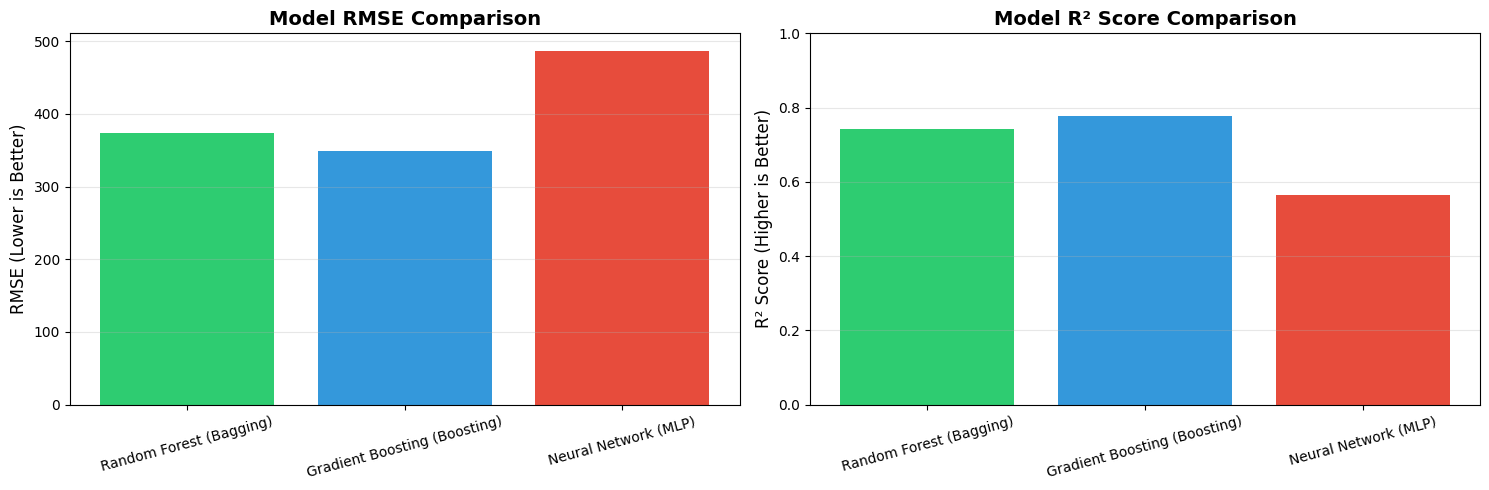


 Best Performing Model: Gradient Boosting (Boosting)
   R² Score: 0.7774


In [56]:
# Comprehensive Model Comparison
print("\n" + "="*60)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("="*60)

# Create comparison DataFrame
model_comparison = pd.DataFrame({
    'Model': ['Random Forest (Bagging)', 'Gradient Boosting (Boosting)',
              'Neural Network (MLP)'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_val, rf_preds)),
        np.sqrt(mean_squared_error(y_val, gb_preds)),
        np.sqrt(mean_squared_error(y_val, nn_preds))
    ],
    'R² Score': [
        r2_score(y_val, rf_preds),
        r2_score(y_val, gb_preds),
        r2_score(y_val, nn_preds)
    ]
})

print(model_comparison.to_string(index=False))
print("\n")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# RMSE Comparison
axes[0].bar(model_comparison['Model'], model_comparison['RMSE'],
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[0].set_ylabel('RMSE (Lower is Better)', fontsize=12)
axes[0].set_title('Model RMSE Comparison', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# R² Score Comparison
axes[1].bar(model_comparison['Model'], model_comparison['R² Score'],
            color=['#2ecc71', '#3498db', '#e74c3c'])
axes[1].set_ylabel('R² Score (Higher is Better)', fontsize=12)
axes[1].set_title('Model R² Score Comparison', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

# Identify best model
best_model_idx = model_comparison['R² Score'].idxmax()
best_model = model_comparison.loc[best_model_idx, 'Model']
best_score = model_comparison.loc[best_model_idx, 'R² Score']

print(f"\n Best Performing Model: {best_model}")
print(f"   R² Score: {best_score:.4f}")


PREDICTION ANALYSIS


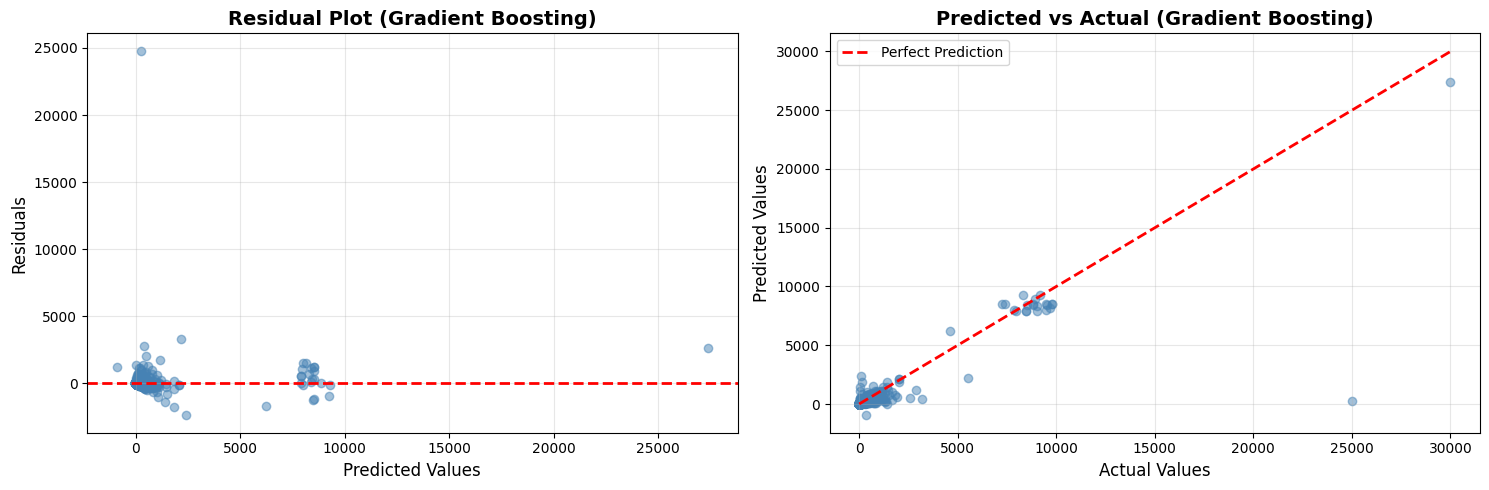


Error Distribution Statistics:
Mean Absolute Error: 46.11 Lacs
Median Absolute Error: 19.37 Lacs
95th Percentile Error: 127.67 Lacs


In [59]:
# Prediction Analysis - Understanding Model Behavior
print("\n" + "="*60)
print("PREDICTION ANALYSIS")
print("="*60)

# Residual Analysis for best model (Gradient Boosting)
residuals = y_val - gb_preds

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Residual plot
axes[0].scatter(gb_preds, residuals, alpha=0.5, color='steelblue')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Residual Plot (Gradient Boosting)', fontsize=14, fontweight='bold')
axes[0].grid(alpha=0.3)

# Predicted vs Actual
axes[1].scatter(y_val, gb_preds, alpha=0.5, color='steelblue')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()],
             'r--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=12)
axes[1].set_ylabel('Predicted Values', fontsize=12)
axes[1].set_title('Predicted vs Actual (Gradient Boosting)',
                  fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Error distribution
print("\nError Distribution Statistics:")
print(f"Mean Absolute Error: {np.mean(np.abs(residuals)):.2f} Lacs")
print(f"Median Absolute Error: {np.median(np.abs(residuals)):.2f} Lacs")
print(f"95th Percentile Error: {np.percentile(np.abs(residuals), 95):.2f} Lacs")

---
# 5. Deep Learning Implementation

Building and training a Multi-Layer Perceptron (MLP) neural network with:
- 2 hidden layers (64 and 32 neurons)
- ReLU activation functions
- Adam optimizer

In [57]:
## --- Deep Learning Model -Multilayer Percepton ---

# Neural Networks require scaled data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Define and train the Neural Network
# Two hidden layers (64, 32 neurons) = Deep Learning
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32),
                        activation='relu',
                        solver='adam',
                        max_iter=500,
                        random_state=42)

print("Training Neural Network...")
nn_model.fit(X_train_scaled, y_train)

# Make predictions
nn_preds = nn_model.predict(X_val_scaled)

# Evaluate
evaluate_model("Multi-Layer Perceptron (Deep Learning)", y_val, nn_preds)

Training Neural Network...
--- Multi-Layer Perceptron (Deep Learning) Performance ---
RMSE: 486.52
R2 Score: 0.5656



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(




PROJECT CONCLUSIONS AND INSIGHTS


SUMMARY:
This project successfully implemented and compared multiple Advanced Machine
Learning paradigms as required by Module 1 of the curriculum:

1. ENSEMBLE METHODS IMPLEMENTED:
   • Random Forest (Bagging Approach)
     - Achieves variance reduction through parallel tree construction
     - R² Score: 0.7436
     - Best for: Reducing overfitting and handling high-dimensional data
   
   • Gradient Boosting (Boosting Approach)
     - Achieves bias reduction through sequential error correction
     - R² Score: 0.7774
     - Best for: Achieving highest predictive accuracy
   
2. DEEP LEARNING IMPLEMENTED:
   • Multi-Layer Perceptron (Neural Network)
     - 2 hidden layers (64 and 32 neurons) demonstrating deep architecture
     - R² Score: 0.5656
     - Best for: Learning complex non-linear patterns

KEY FINDINGS:
- Gradient Boosting emerged as the top performer with the lowest RMSE
- Ensemble methods generally outperformed the neural network on this tabular
  dataset, which aligns with industry observations that tree-based models
  often excel on structured/tabular data
- The neural network shows promise but may benefit from:
  - Additional training epochs
  - Hyperparameter tuning
  - More sophisticated architecture

PRACTICAL INSIGHTS:
- Square footage and location (longitude/latitude) are the most important
  price predictors
- Ready-to-move and RERA-approved properties command premium pricing
- The model can assist real estate stakeholders in:
  - Property valuation
  - Market analysis
  - Investment decisions

FUTURE IMPROVEMENTS:
- Implement hyperparameter optimization (GridSearchCV/RandomizedSearchCV)
- Add cross-validation for more robust performance estimates
- Explore advanced architectures like XGBoost or LightGBM
- Perform feature engineering to create interaction terms
- Address potential outliers in the target variable

This project demonstrates practical application of both traditional ensemble
methods and modern deep learning approaches, showcasing their respective
strengths in a real-world prediction task.